In [2]:
%matplotlib widget

In [3]:
# 3D forward dipping boundary

# Script to create synthetic 3D data

import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
from joblib import Parallel, delayed
import sys
sys.path.insert(1, 'src')

In [4]:
data = np.load('dataUR.npy')

In [5]:
alphas = np.arange(-10, 10)
sigmas = np.array([[20/1000, 200/1000],
                   [20/1000, 400/1000],
                   [20/1000, 800/1000],
                   [20/1000, 1600/1000]])

idx=np.argmin(np.abs(alphas))

In [6]:
data = data.reshape((len(alphas), len(sigmas), 18))

In [7]:
dat_0 = np.zeros_like(data)

for i, a in enumerate(alphas):
    for j, s in enumerate(sigmas):
        dat_0[i, j, :] = data[idx, j, :]

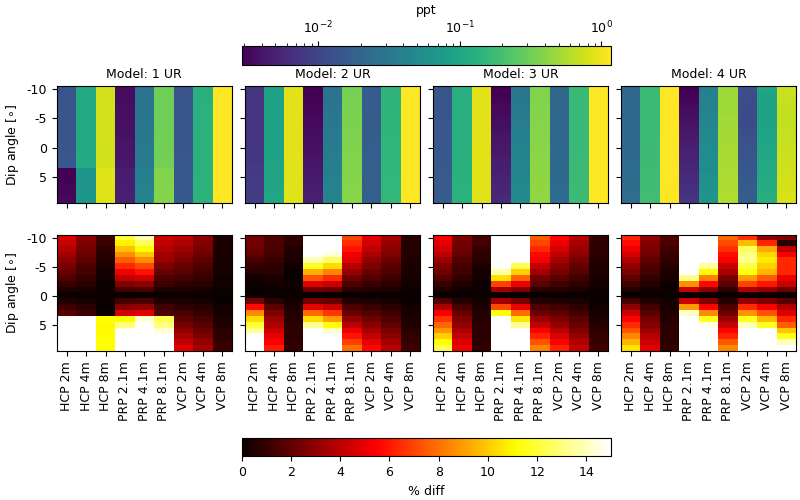

In [8]:
fig, axs = plt.subplots(2,4, figsize=(8, 5), sharex=True, sharey=True, layout='constrained')

ax = axs.ravel()
cmap='hot'
fs=9
keys = ['HCP 2m', 'HCP 4m', 'HCP 8m', 'PRP 2.1m', 'PRP 4.1m', 'PRP 8.1m', 'VCP 2m', 'VCP 4m', 'VCP 8m',] 

for i, s in enumerate(sigmas):
    j = i
    c1 = ax[j].imshow(data[:, i, :9]*1000, aspect = .3, norm='log') 
    ax[j].set_title('Model: ' + str(i+1) +' UR', fontsize=fs)
    
   # ax[j+8].imshow(data[:, i, 9:].T, aspect = 5) 
    c2 = ax[j+4].imshow(np.abs((data[:,i, :9] - dat_0[:,i,:9])/dat_0[:, i, :9])*100, cmap=cmap, aspect=.3, vmin=0, vmax=15)
    
    ax[j].set_xticks(np.arange(0,9))
    ax[j+4].set_xticklabels(keys, rotation ='vertical')
    ax[j].set_yticks(np.arange(0,20,5))
    ax[j].set_yticklabels(['-10', '-5', '0', '5', ], )
    ax[j].tick_params(labelsize=fs)
    ax[j+4].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location = 'top', shrink=0.5, pad = 0.01)
cb2 = fig.colorbar(c2, ax=ax, location = 'bottom', shrink=0.5, pad=0.05)

axs[0,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
axs[1,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)

cb2.ax.tick_params(labelsize=fs)
cb2.set_label('% diff', fontsize=fs)

cb1.ax.tick_params(labelsize=fs)
cb1.set_label('ppt', fontsize=fs)

plt.savefig('DippingBoundaryUR_Q.eps', format='eps')

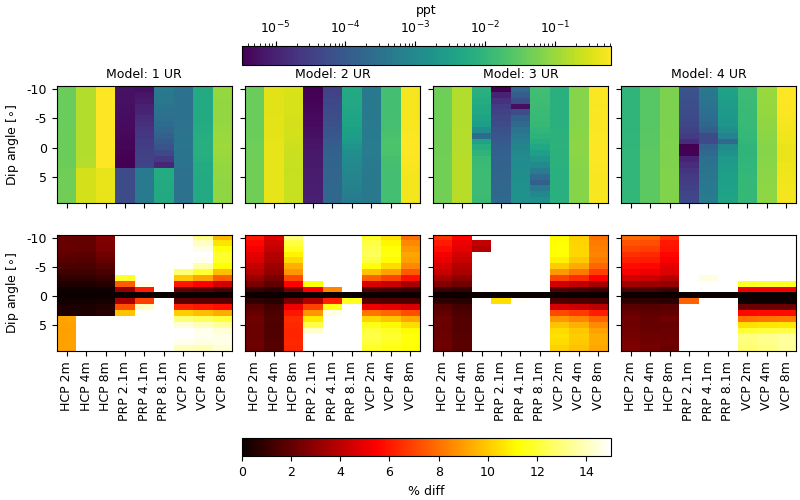

In [9]:
fig, axs = plt.subplots(2,4, figsize=(8, 5), sharex=True, sharey=True, layout='constrained')

ax = axs.ravel()
cmap='hot'
fs=9
keys = ['HCP 2m', 'HCP 4m', 'HCP 8m', 'PRP 2.1m', 'PRP 4.1m', 'PRP 8.1m', 'VCP 2m', 'VCP 4m', 'VCP 8m',] 

for i, s in enumerate(sigmas):
    j = i
    c1 = ax[j].imshow(data[:, i, 9:]*1000, aspect = .3, norm='log') 
    ax[j].set_title('Model: ' + str(i+1) +' UR', fontsize=fs)
    
   # ax[j+8].imshow(data[:, i, 9:].T, aspect = 5) 
    c2 = ax[j+4].imshow(np.abs((data[:,i, 9:] - dat_0[:,i,9:])/dat_0[:, i, 9:])*100, cmap=cmap, aspect=.3, vmin=0, vmax=15)
    
    ax[j].set_xticks(np.arange(0,9))
    ax[j+4].set_xticklabels(keys, rotation ='vertical')
    ax[j].set_yticks(np.arange(0,20,5))
    ax[j].set_yticklabels(['-10', '-5', '0', '5', ], )
    ax[j].tick_params(labelsize=fs)
    ax[j+4].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location = 'top', shrink=0.5, pad = 0.01)
cb2 = fig.colorbar(c2, ax=ax, location = 'bottom', shrink=0.5, pad=0.05)

axs[0,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
axs[1,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)

cb2.ax.tick_params(labelsize=fs)
cb2.set_label('% diff', fontsize=fs)

cb1.ax.tick_params(labelsize=fs)
cb1.set_label('ppt', fontsize=fs)

plt.savefig('DippingBoundaryUR_IP.eps', format='eps')

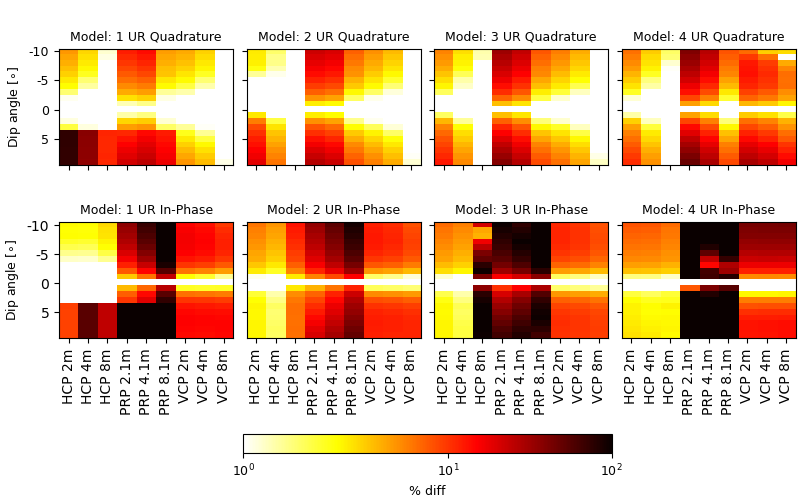

In [10]:
fig, axs = plt.subplots(2,4, figsize=(8, 5), sharex=True, sharey=True, layout='constrained')

ax = axs.ravel()
cmap='hot_r'
fs=9
keys = ['HCP 2m', 'HCP 4m', 'HCP 8m', 'PRP 2.1m', 'PRP 4.1m', 'PRP 8.1m', 'VCP 2m', 'VCP 4m', 'VCP 8m', ] 

for i, s in enumerate(sigmas):
    j = i
    c1 = ax[j].imshow(np.abs((data[:,i, :9] - dat_0[:,i,:9])/dat_0[:, i, :9])*100, cmap=cmap, aspect=.3, vmin=1, vmax=100, norm='symlog')
    c2 = ax[j+4].imshow(np.abs((data[:,i, 9:] - dat_0[:,i,9:])/dat_0[:, i, 9:])*100, cmap=cmap, aspect=.3, vmin=1, vmax=100, norm='symlog')
    ax[j].set_title('Model: ' + str(i+1) +' UR Quadrature', fontsize=fs)
    ax[j+ 4].set_title('Model: ' + str(i+1) +' UR In-Phase', fontsize=fs)
    
    ax[j].set_xticks(np.arange(0,9))
    ax[j+4].set_xticklabels(keys, rotation ='vertical')
    ax[j].set_yticks(np.arange(0,20,5))
    ax[j].set_yticklabels(['-10', '-5', '0', '5', ], )
    ax[j].tick_params(labelsize=fs)
    ax[j].tick_params(labelsize=fs)

#cb1 = fig.colorbar(c1, ax=ax, location = 'top', shrink=0.5, pad = 0.01)
cb2 = fig.colorbar(c2, ax=ax, location = 'bottom', shrink=0.5, pad=0.05)

axs[0,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
axs[1,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)

cb2.ax.tick_params(labelsize=fs)
cb2.set_label('% diff', fontsize=fs)

#cb1.ax.tick_params(labelsize=fs)
#cb1.set_label('ppt', fontsize=fs)

plt.savefig('DippingBoundaryUR.eps', format='eps')

In [19]:
import pandas as pd

difference = np.abs(data*1000 - dat_0*1000)

diff = pd.DataFrame(difference.reshape(20*4,18), columns = ['HCP_2m_Q', 'HCP_4m_Q', 'HCP_8m_Q', 'PRP_2.1m_Q', 'PRP_4.1m_Q', 'PRP_8.1m_Q',
                                                            'VCP_2m_Q', 'VCP_4m_Q', 'VCP_8m_Q', 'HCP_2m_IP', 'HCP_4m_IP', 'HCP_8m_IP',
                                                            'PRP_2.1m_IP', 'PRP_4.1m_IP', 'PRP_8.1m_IP', 'VCP_2m_IP', 'VCP_4m_IP', 'VCP_8m_IP', ] )

case = []

for a in alphas:
    for s in range(len(sigmas)):
        case.append([a, s+1])

case = np.array(case)

diff['alpha'] = case[:,0]
diff['case'] = case[:,1]

diff.to_pickle('difference.pkl')

In [10]:
diff

,HCP_2m_Q,HCP_4m_Q,HCP_8m_Q,PRP_2.1m_Q,PRP_4.1m_Q,PRP_8.1m_Q,VCP_2m_Q,VCP_4m_Q,VCP_8m_Q,HCP_2m_IP,HCP_4m_IP,HCP_8m_IP,PRP_2.1m_IP,PRP_4.1m_IP,PRP_8.1m_IP,VCP_2m_IP,VCP_4m_IP,VCP_8m_IP,alpha,case
0,0.000224,0.000819,0.001797,0.000191,0.001339,0.003161,0.000196,0.000998,0.000854,0.000145,0.000372,0.001297,0.000003,0.000028,0.000212,0.000037,0.000254,0.001278,-10,1
1,0.000092,0.000641,0.002708,0.000460,0.003272,0.009957,0.000419,0.002177,0.002650,0.000531,0.001480,0.003113,0.000022,0.000172,0.001324,0.000088,0.000612,0.003229,-10,2
2,0.000558,0.002301,0.008115,0.000943,0.006720,0.020601,0.000864,0.004535,0.006535,0.000651,0.001828,0.000336,0.000041,0.000190,0.002587,0.000231,0.001627,0.009112,-10,3
3,0.001432,0.005435,0.018706,0.001901,0.013547,0.041384,0.000877,0.003077,0.019772,0.000786,0.002211,0.003921,0.000071,0.000274,0.002571,0.004107,0.030152,0.192227,-10,4
4,0.000204,0.000743,0.001677,0.000174,0.001221,0.002940,0.000178,0.000906,0.000812,0.000139,0.000358,0.001223,0.000003,0.000026,0.000196,0.000039,0.000270,0.001402,-9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.002153,0.007682,0.008910,0.001987,0.013056,0.039491,0.003344,0.021260,0.100914,0.000254,0.000664,0.001353,0.000038,0.000348,0.002707,0.001251,0.009194,0.059399,8,4
76,0.003505,0.010127,0.016620,0.000337,0.002426,0.012045,0.000230,0.001172,0.002334,0.000613,0.009567,0.011462,0.000054,0.000265,0.001511,0.000035,0.000268,0.001901,9,1
77,0.000699,0.002405,0.002839,0.000557,0.003644,0.011252,0.000474,0.002403,0.004750,0.000196,0.000511,0.001503,0.000013,0.000098,0.000721,0.000088,0.000660,0.004526,9,2
78,0.001280,0.004467,0.005410,0.001141,0.007447,0.022682,0.000955,0.004822,0.009503,0.000224,0.000580,0.001582,0.000027,0.000211,0.000774,0.000212,0.001580,0.010470,9,3
